# Preparation

In [1]:
from pprint import pprint
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from matplotlib import pyplot as plt
import os
from datasets.data_processing import preprocess_df
from datasets.telco import load_telco_df
from gragod import start_research
from gragod.metrics.calculator import MetricsCalculator, get_metrics
from gragod.metrics.visualization import plot_single_score_histogram
from gragod.predictions.prediction import get_threshold_system
from gragod.predictions.spot import SPOT
from gragod.training import load_params
from gragod.types import Datasets, Models, ParamFileTypes
from models.predict import predict

Working on /Users/gonza/facultad/tesis/GraGOD
Loaded .env file: False


In [2]:
dataset = Datasets.SWAT.value


def load_dataset_predictions(model_name: str, dataset_name: str, split: str = "test"):
    data_path = f"../results/test_{dataset_name}/{model_name}/version_0/predictions/{split}_{model_name}_{dataset_name}_data.pt"
    labels_path = f"../results/test_{dataset_name}/{model_name}/version_0/predictions/{split}_{model_name}_{dataset_name}_labels.pt"
    output_path = f"../results/test_{dataset_name}/{model_name}/version_0/predictions/{split}_{model_name}_{dataset_name}_output.pt"
    predictions_path = f"../results/test_{dataset_name}/{model_name}/version_0/predictions/{split}_{model_name}_{dataset_name}_predictions.pt"
    scores_path = f"../results/test_{dataset_name}/{model_name}/version_0/predictions/{split}_{model_name}_{dataset_name}_scores.pt"
    threshold_path = f"../results/test_{dataset_name}/{model_name}/version_0/predictions/{split}_{model_name}_{dataset_name}_thresholds.pt"

    data = torch.load(data_path)
    labels = torch.load(labels_path)
    output = torch.load(output_path)
    predictions = torch.load(predictions_path)
    scores = torch.load(scores_path)
    threshold = torch.load(threshold_path)

    labels_single = (torch.sum(labels, dim=1) > 0).int()
    predictions_single = (torch.sum(predictions, dim=1) > 0).int()
    scores_single = torch.mean(scores, dim=1)[0]

    return (
        data,
        labels,
        output,
        predictions,
        scores,
        labels_single,
        scores_single,
        predictions_single,
        threshold,
    )


def load_graph_model_predictions(
    model_name: str, dataset_name: str, split: str = "test"
):
    data_path = f"../results/{model_name}_{dataset_name}_graph/{split}_{model_name}_{dataset_name}_data.pt"
    labels_path = f"../results/{model_name}_{dataset_name}_graph/{split}_{model_name}_{dataset_name}_labels.pt"
    output_path = f"../results/{model_name}_{dataset_name}_graph/{split}_{model_name}_{dataset_name}_output.pt"
    predictions_path = f"../results/{model_name}_{dataset_name}_graph/{split}_{model_name}_{dataset_name}_predictions.pt"
    scores_path = f"../results/{model_name}_{dataset_name}_graph/{split}_{model_name}_{dataset_name}_scores.pt"
    threshold_path = f"../results/{model_name}_{dataset_name}_graph/{split}_{model_name}_{dataset_name}_thresholds.pt"

    data = torch.load(data_path)
    labels = torch.load(labels_path)
    output = torch.load(output_path)
    predictions = torch.load(predictions_path)
    scores = torch.load(scores_path)
    threshold = torch.load(threshold_path)

    labels_single = (torch.sum(labels, dim=1) > 0).int()
    predictions_single = (torch.sum(predictions, dim=1) > 0).int()
    scores_single = torch.mean(scores, dim=1)[0]

    return (
        data,
        labels,
        output,
        predictions,
        scores,
        labels_single,
        scores_single,
        predictions_single,
        threshold,
    )


(
    data_gru_val,
    labels_gru_val,
    output_gru_val,
    predictions_gru_val,
    scores_gru_val,
    labels_gru_single_val,
    scores_gru_single_val,
    predictions_gru_single_val,
    threshold_gru_val,
) = load_dataset_predictions("gru", "swat", split="val")

(
    data_mtad_gat_val,
    labels_mtad_gat_val,
    output_mtad_gat_val,
    predictions_mtad_gat_val,
    scores_mtad_gat_val,
    labels_mtad_gat_single_val,
    scores_mtad_gat_single_val,
    predictions_mtad_gat_single_val,
    threshold_mtad_gat_val,
) = load_dataset_predictions("mtad_gat", "swat", split="val")
(
    data_gru_test,
    labels_gru_test,
    output_gru_test,
    predictions_gru_test,
    scores_gru_test,
    labels_gru_single_test,
    scores_gru_single_test,
    predictions_gru_single_test,
    threshold_gru_test,
) = load_dataset_predictions("gru", "swat", split="test")
(
    data_mtad_gat_test,
    labels_mtad_gat_test,
    output_mtad_gat_test,
    predictions_mtad_gat_test,
    scores_mtad_gat_test,
    labels_mtad_gat_single_test,
    scores_mtad_gat_single_test,
    predictions_mtad_gat_single_test,
    threshold_mtad_gat_test,
) = load_dataset_predictions("mtad_gat", "swat", split="test")
(
    data_gdn_graph_test,
    labels_gdn_graph_test,
    output_gdn_graph_test,
    predictions_gdn_graph_test,
    scores_gdn_graph_test,
    labels_gdn_graph_single_test,
    scores_gdn_graph_single_test,
    predictions_gdn_graph_single_test,
    threshold_gdn_graph_test,
) = load_graph_model_predictions("gdn", "swat", split="test")
(
    data_gdn_graph_val,
    labels_gdn_graph_val,
    output_gdn_graph_val,
    predictions_gdn_graph_val,
    scores_gdn_graph_val,
    labels_gdn_graph_single_val,
    scores_gdn_graph_single_val,
    predictions_gdn_graph_single_val,
    threshold_gdn_graph_val,
) = load_graph_model_predictions("gdn", "swat", split="val")
(
    data_gdn_test,
    labels_gdn_test,
    output_gdn_test,
    predictions_gdn_test,
    scores_gdn_test,
    labels_gdn_single_test,
    scores_gdn_single_test,
    predictions_gdn_single_test,
    threshold_gdn_test,
) = load_dataset_predictions("gdn", "swat", split="test")
(
    data_gdn_val,
    labels_gdn_val,
    output_gdn_val,
    predictions_gdn_val,
    scores_gdn_val,
    labels_gdn_single_val,
    scores_gdn_single_val,
    predictions_gdn_single_val,
    threshold_gdn_val,
) = load_dataset_predictions("gdn", "swat", split="val")

(
    data_gcn_val,
    labels_gcn_val,
    output_gcn_val,
    predictions_gcn_val,
    scores_gcn_val,
    labels_gcn_single_val,
    scores_gcn_single_val,
    predictions_gcn_single_val,
    threshold_gcn_val,
) = load_dataset_predictions("gcn", "swat", split="val")
(
    data_gcn_test,
    labels_gcn_test,
    output_gcn_test,
    predictions_gcn_test,
    scores_gcn_test,
    labels_gcn_single_test,
    scores_gcn_single_test,
    predictions_gcn_single_test,
    threshold_gcn_test,
) = load_dataset_predictions("gcn", "swat", split="test")

## Load SWAT columns

In [3]:
from datasets.swat import load_swat_df

path_to_dataset = "datasets_files/swat"
(
    df_train,
    df_train_labels,
    df_val,
    df_val_labels,
    df_test,
    df_test_labels,
    ) = load_swat_df()

# Remove whitespaces from column names
df_train.columns = df_train.columns.str.strip()
df_val.columns = df_val.columns.str.strip()
df_test.columns = df_test.columns.str.strip()

# Drop timestamps from the dataframes (TODO: Add this to dataset config)
columns_to_drop = [
    "Timestamp",
    "P102",
    "P201",
    "P202",
    "P204",
    "P206",
    "P401",
    "P402",
    "P403",
    "P404",
    "UV401",
    "P501",
    "P502",
    "P601",
    "P603",
]
df_train = df_train.drop(columns=columns_to_drop)
df_val = df_val.drop(columns=columns_to_drop)
df_test = df_test.drop(columns=columns_to_drop)

cols = df_train.columns

# Plotting function

In [4]:
from PIL import Image
import math
def generate_forecast_and_series_fig(y_pred, y_true, labels, model_name, dataset_name, fig_name, plot_legend=False, title=None):
    """
    Generate a figure with the forecast and the series, without plotting the figure
    """
    if not os.path.exists("figures"):
        os.makedirs("figures")
    if not os.path.exists(os.path.join("figures", dataset_name)):
        os.makedirs(os.path.join("figures", dataset_name))
    if not os.path.exists(os.path.join("buffer")):
        os.makedirs(os.path.join("buffer"))
    if not os.path.exists(os.path.join("buffer", dataset_name)):
        os.makedirs(os.path.join("buffer", dataset_name))
    

    fig = plt.figure(figsize=(14, 10))
    plt.plot(y_pred, label="Forecast", color="green", linewidth=3)
    plt.plot(y_true, label="Data", color="blue", linewidth=3)

    # Add background color based on labels using fill_between
    ax = plt.gca()
    x = np.arange(len(labels))

    xticks = [0, len(x), len(x) // 2]
    plt.xticks(xticks, [f"{tick}" for tick in xticks], fontsize=50)
    # yticks = np.linspace(min(plt.yticks()[0]), max(plt.yticks()[0]), 5)
    # plt.yticks(yticks, [f"{tick:.1f}" for tick in yticks], fontsize=20)
    min_y = math.floor(min(torch.min(y_pred), torch.min(y_true)) * 10) / 10
    max_y = math.ceil(max(torch.max(y_pred), torch.max(y_true)) * 10) / 10
    plt.yticks([min_y, max_y], [f"{min_y:.1f}", f"{max_y:.1f}"], fontsize=50)
    if plot_legend:
        plt.legend(fontsize=50, title_fontsize=50)
    # plt.grid(True)
    idx_ranges = []
    anomaly_indices = np.where(labels == 1)[0]
    for k, g in itertools.groupby(
        enumerate(anomaly_indices), lambda x: x[0] - x[1]
    ):
        group = list(map(lambda x: x[1], g))
        idx_ranges.append((group[0], group[-1]))

    for start, end in idx_ranges:
        plt.axvspan(start , end , color="red", alpha=0.2)
    if title:
        plt.title(title, fontsize=50)
    # save fig
    plt.savefig(os.path.join("buffer", dataset_name, fig_name))
    plt.savefig(os.path.join("figures", dataset_name, fig_name.replace(".png", ".pdf")))
    plt.close(fig)
    # return 


def generate_grid(figs_paths: list[str], cols: int, file_name: str):
    # Load all images as PIL Images
    images = [Image.open(os.path.join("buffer", path)) for path in figs_paths]
    
    # Calculate grid dimensions
    rows = (len(images) + cols - 1) // cols
    width, height = images[0].size  # Assume all images are same size
    
    # Create combined image
    combined = Image.new('RGB', (cols * width, rows * height))
    
    # Paste images into grid
    for i, img in enumerate(images):
        row = i // cols
        col = i % cols
        combined.paste(img, (col * width, row * height))
    
    # save combined image
    combined.save(os.path.join("buffer", file_name))
    combined.save(os.path.join("figures", file_name.replace(".png", ".pdf")))
    return combined





# Benchmark Analysis

## How does anomalies in one series affect the predictions of the other series?

### example 1

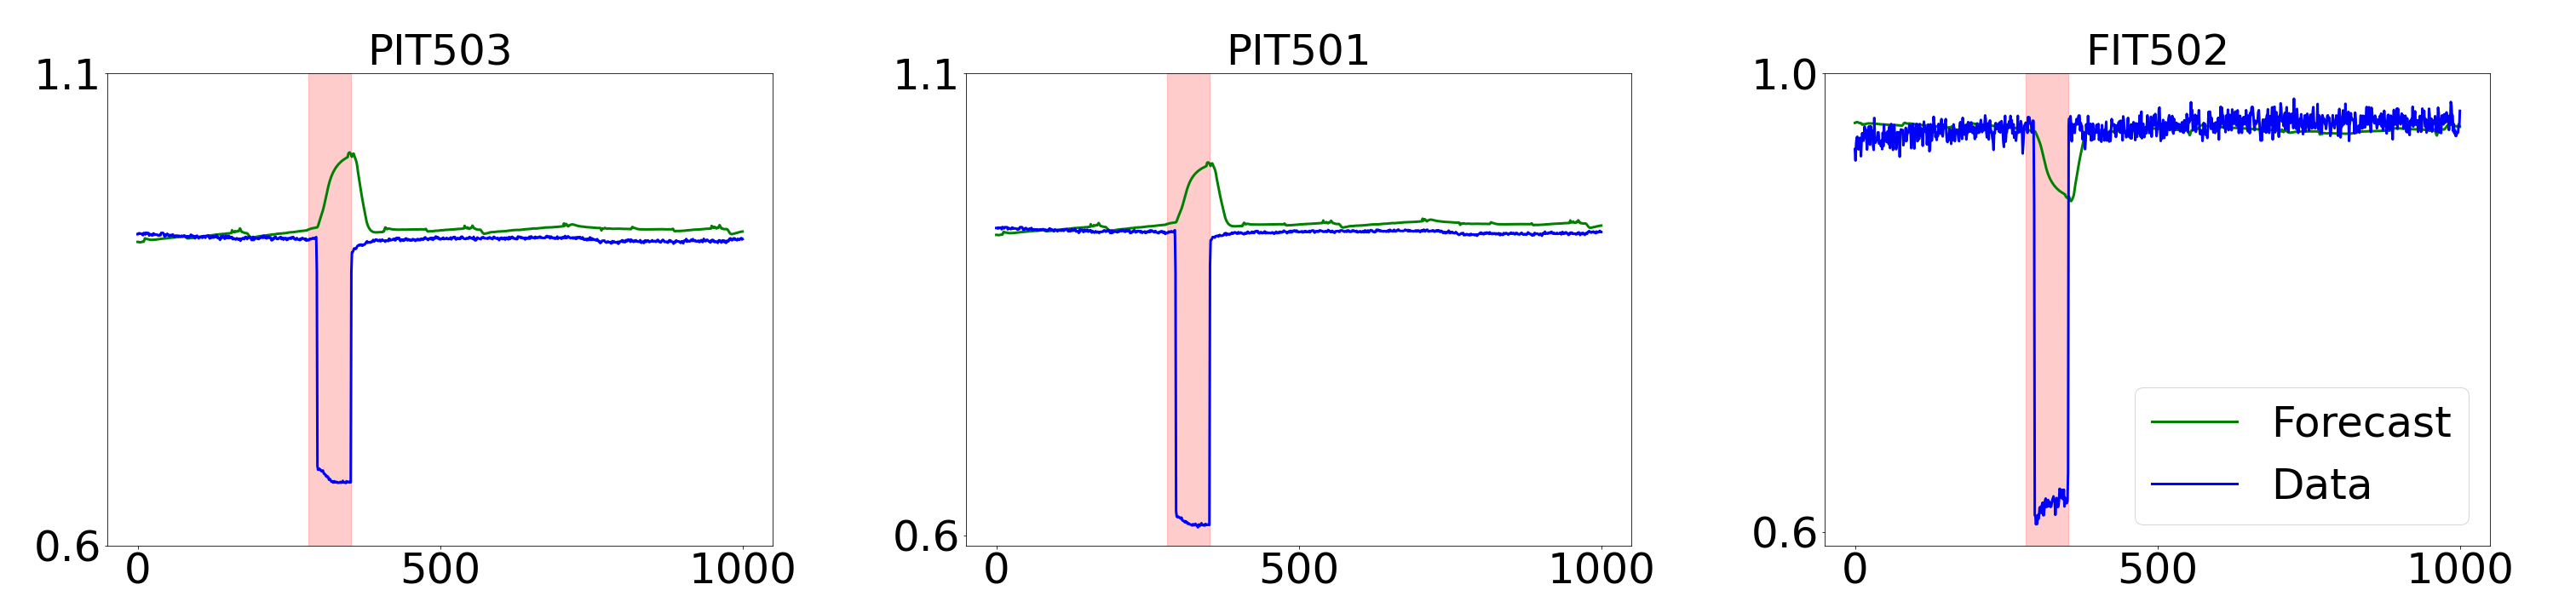

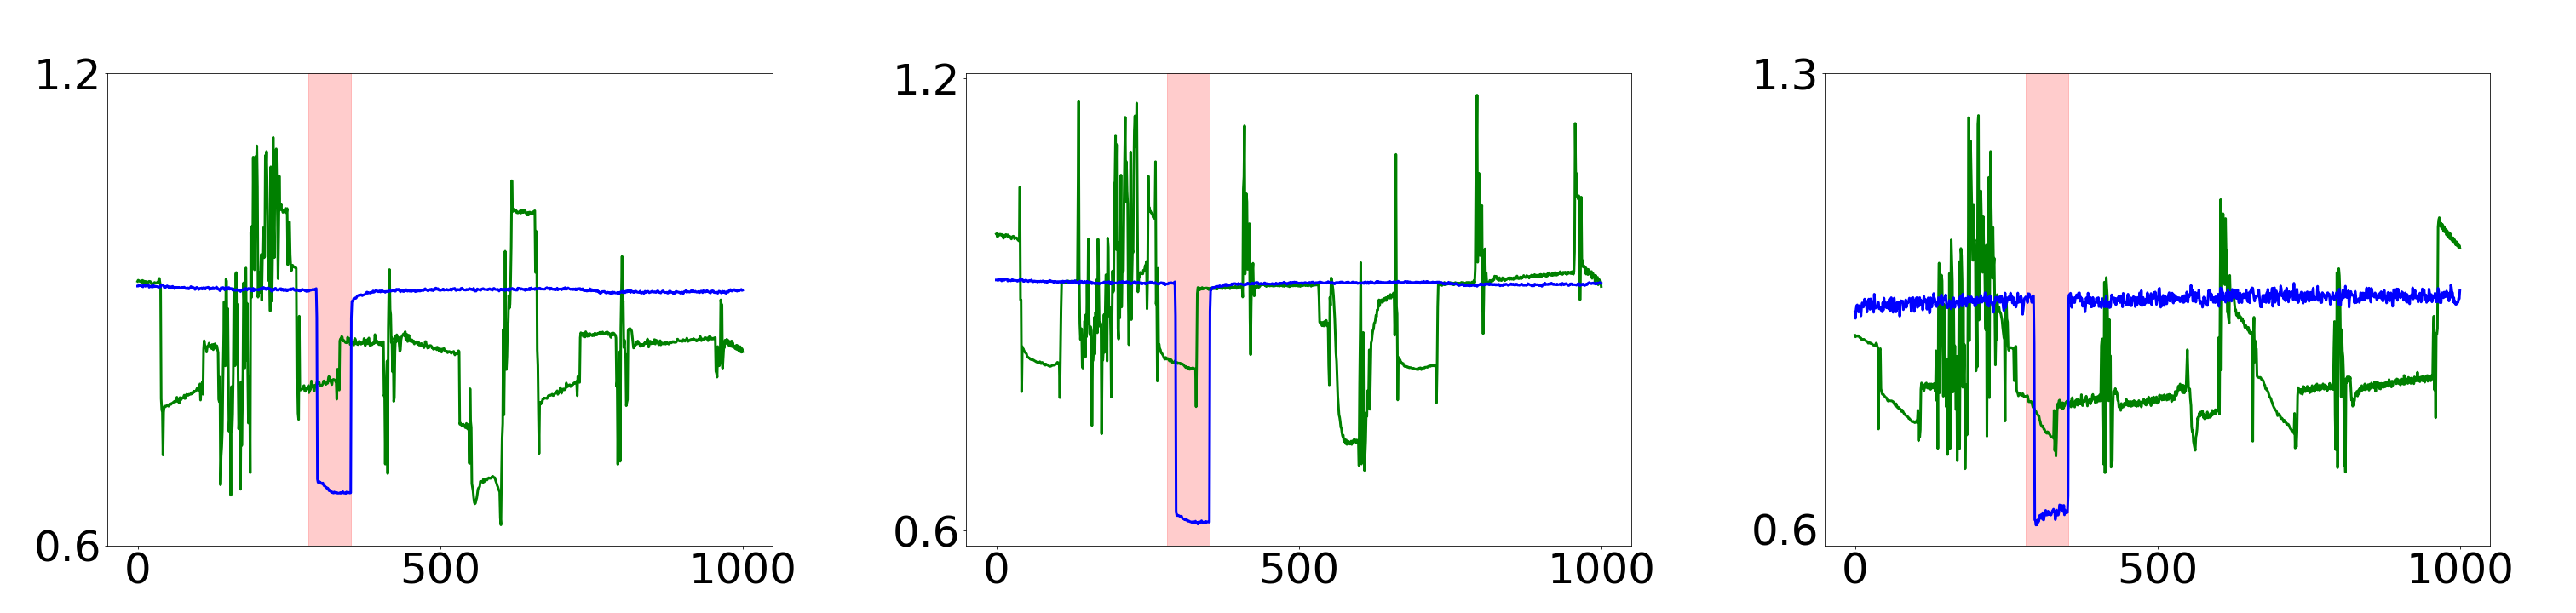

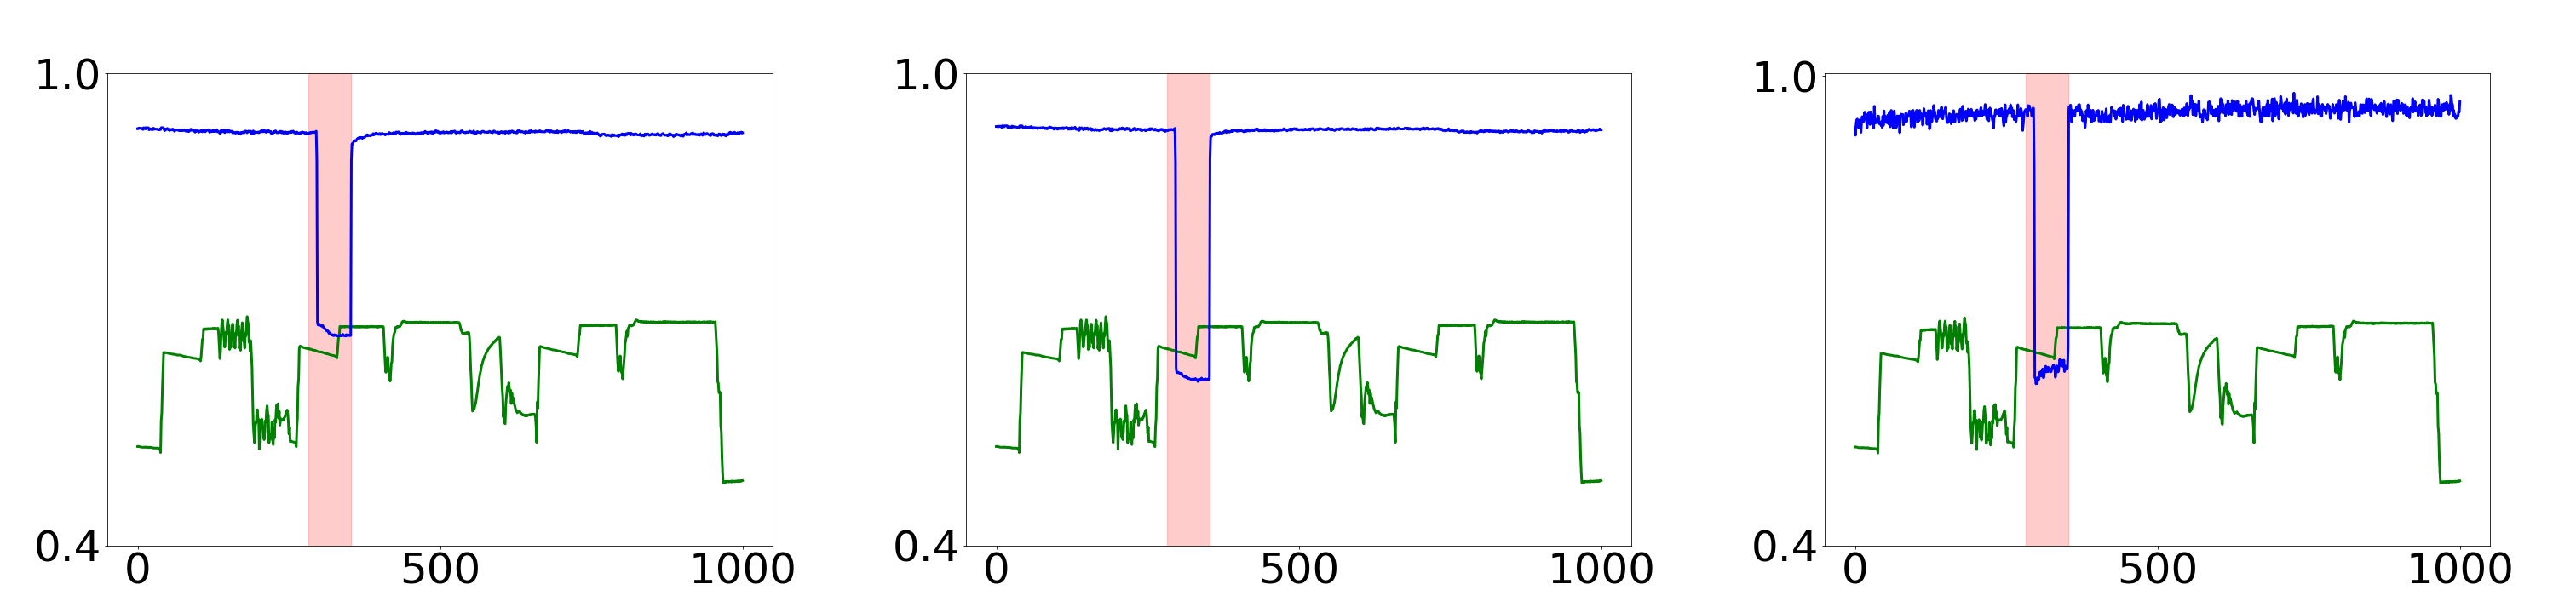

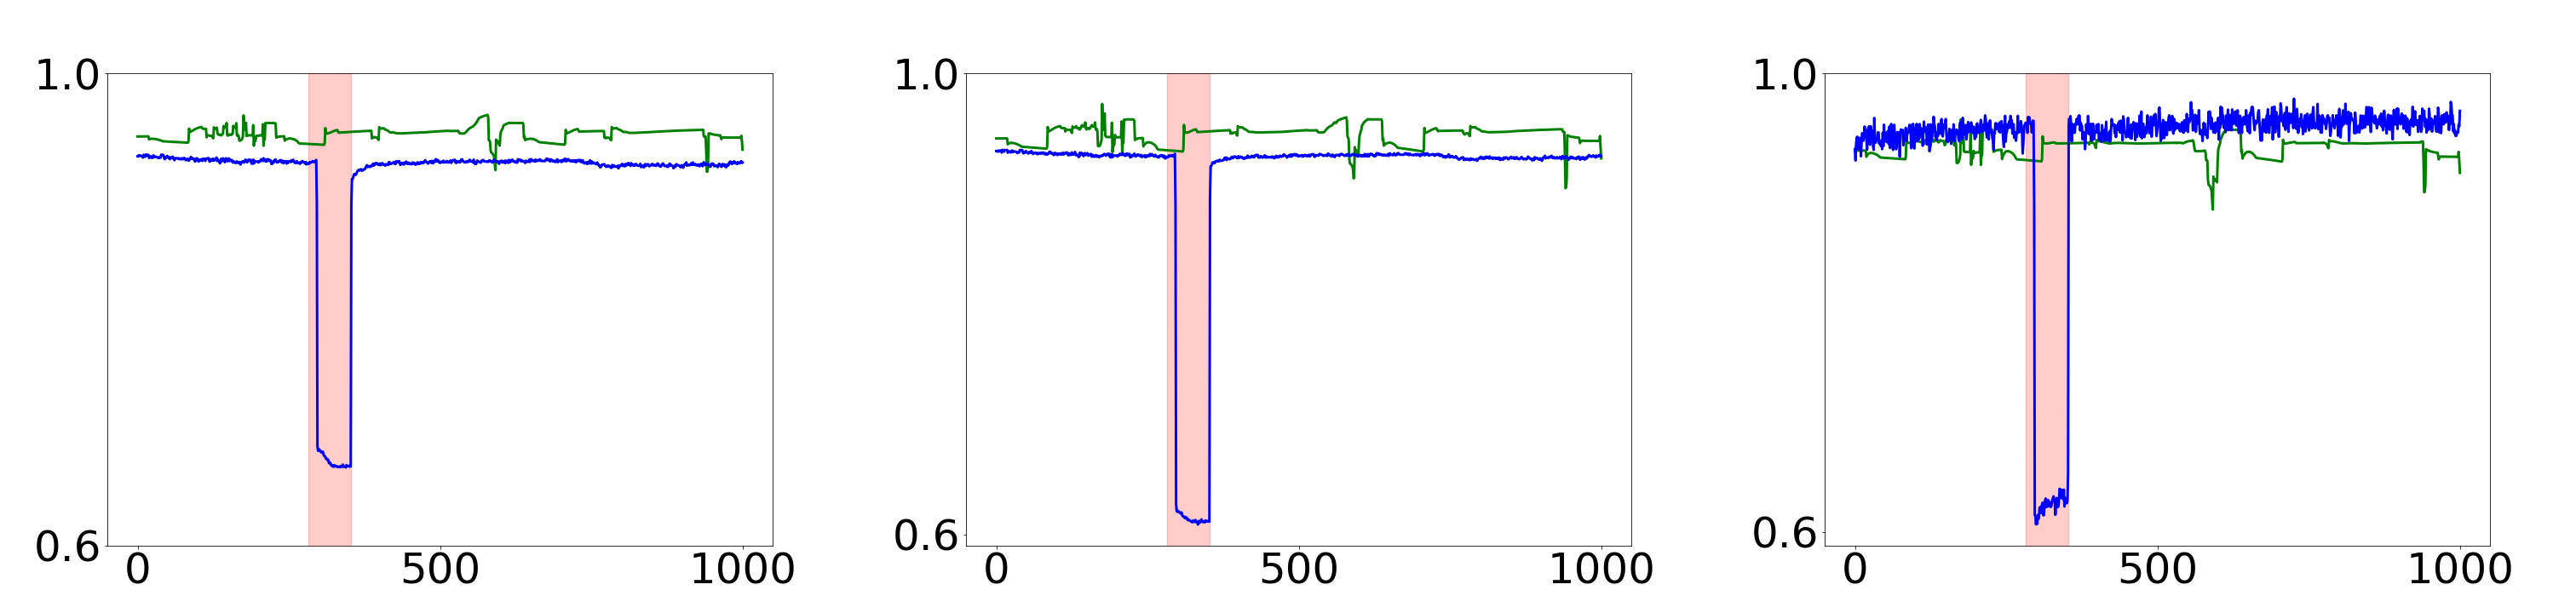

In [6]:
anomaly_columns = [34, 32, 29]
non_anomaly_columns = [10, 9, 8]

custom_start_index = 1000
custom_end_index = 2000
gru_figs = []
for column in anomaly_columns:
    
    generate_forecast_and_series_fig(
        output_gru_val[custom_start_index:custom_end_index, column],
        data_gru_val[custom_start_index:custom_end_index, column],
        labels_gru_single_val[custom_start_index:custom_end_index],
        "GRU",
        "SWAT",
        f"gru_anomaly_{column}.png",
        plot_legend=column == 29,
        title=cols[column]
    )
    gru_figs.append(
        f"gru_anomaly_{column}.png"
    )
    
 
display(generate_grid(gru_figs, cols=3, file_name="gru_anomaly_grid.png"))


# Generate grid for GDN figures
gdn_figs = []
for column in anomaly_columns:
    
    generate_forecast_and_series_fig(
        output_gdn_val[custom_start_index:custom_end_index, column],
        data_gdn_val[custom_start_index:custom_end_index, column],
        labels_gdn_single_val[custom_start_index:custom_end_index],
        "GDN",
        "SWAT",
        f"gdn_anomaly_{column}.png"
    )
    gdn_figs.append(
        f"gdn_anomaly_{column}.png"
    )

display(generate_grid(gdn_figs, cols=3, file_name="gdn_anomaly_grid.png"))

# Generate grid for GCN figures
gcn_figs = []
for column in anomaly_columns:
   
    generate_forecast_and_series_fig(
        output_gcn_val[custom_start_index:custom_end_index, column],
        data_gcn_val[custom_start_index:custom_end_index, column],
        labels_gcn_single_val[custom_start_index:custom_end_index],
        "GCN",
        "SWAT",
        f"gcn_anomaly_{column}.png" 
    )
    gcn_figs.append(
        f"gcn_anomaly_{column}.png"
    )

display(generate_grid(gcn_figs, cols=3, file_name="gcn_anomaly_grid.png"))

mtad_gat_figs = []
mtad_gat_forecasts, mtad_gat_reconstruction = output_mtad_gat_val
for column in anomaly_columns:
    generate_forecast_and_series_fig(
        mtad_gat_forecasts[custom_start_index:custom_end_index, column],
        data_mtad_gat_val[custom_start_index:custom_end_index, column],
        labels_mtad_gat_single_val[custom_start_index:custom_end_index],
        "MTAD-GAT",
        "SWAT",
        f"mtad_gat_anomaly_{column}.png"
    )
    mtad_gat_figs.append(
        f"mtad_gat_anomaly_{column}.png"
    )

display(generate_grid(mtad_gat_figs, cols=3, file_name="mtad_gat_anomaly_grid.png"))

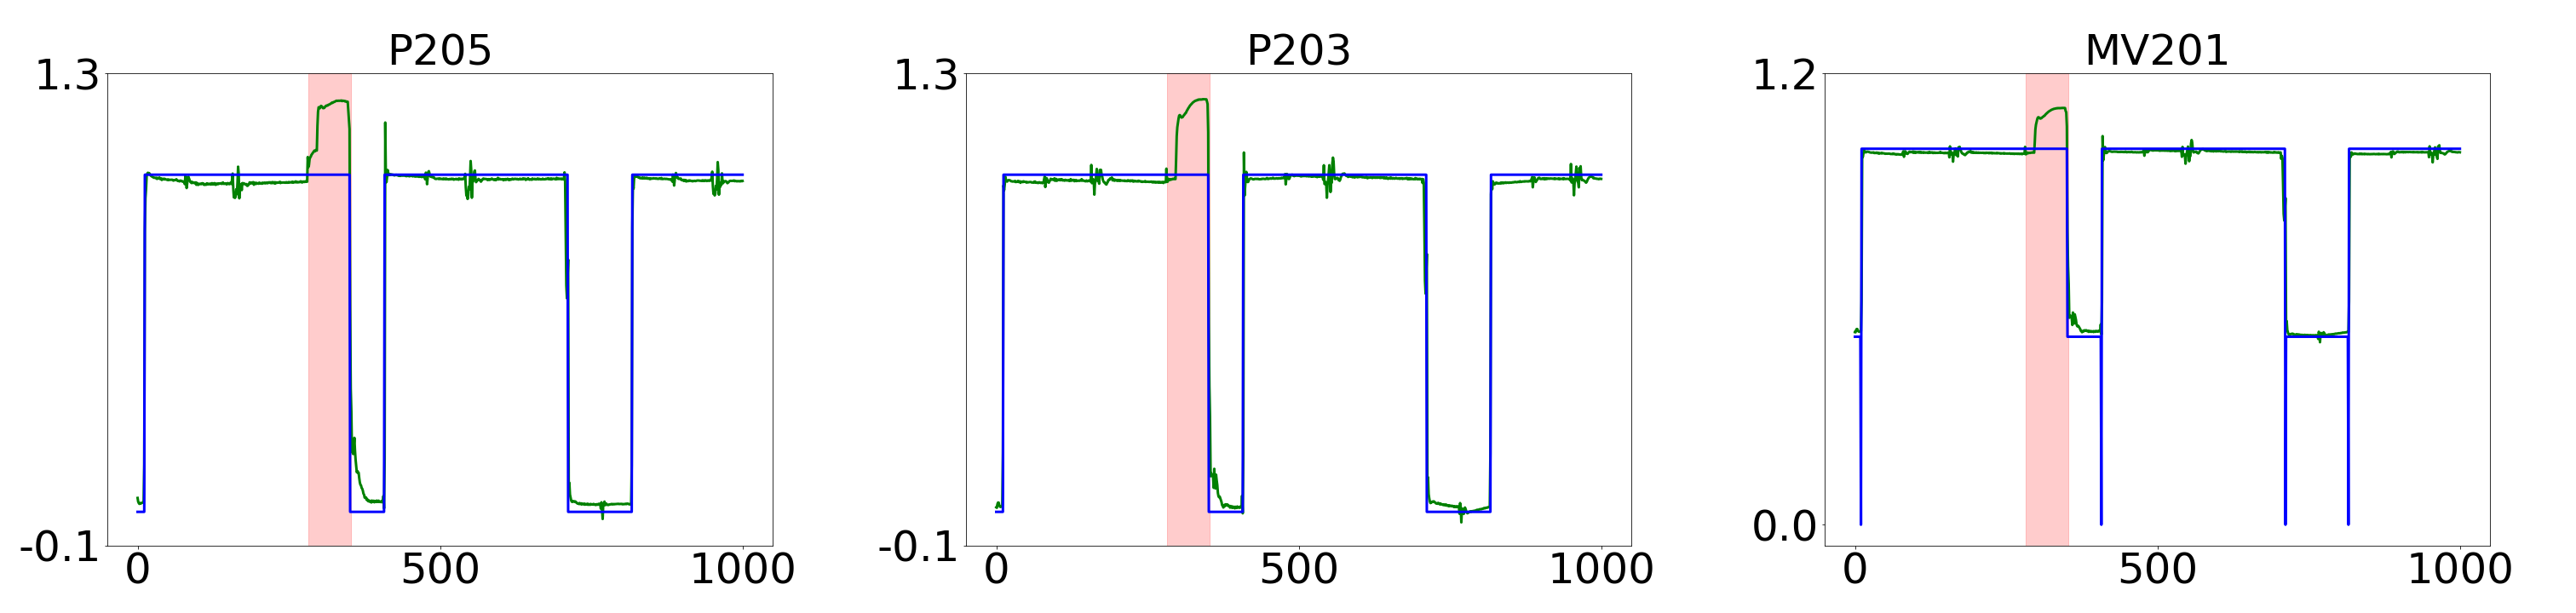

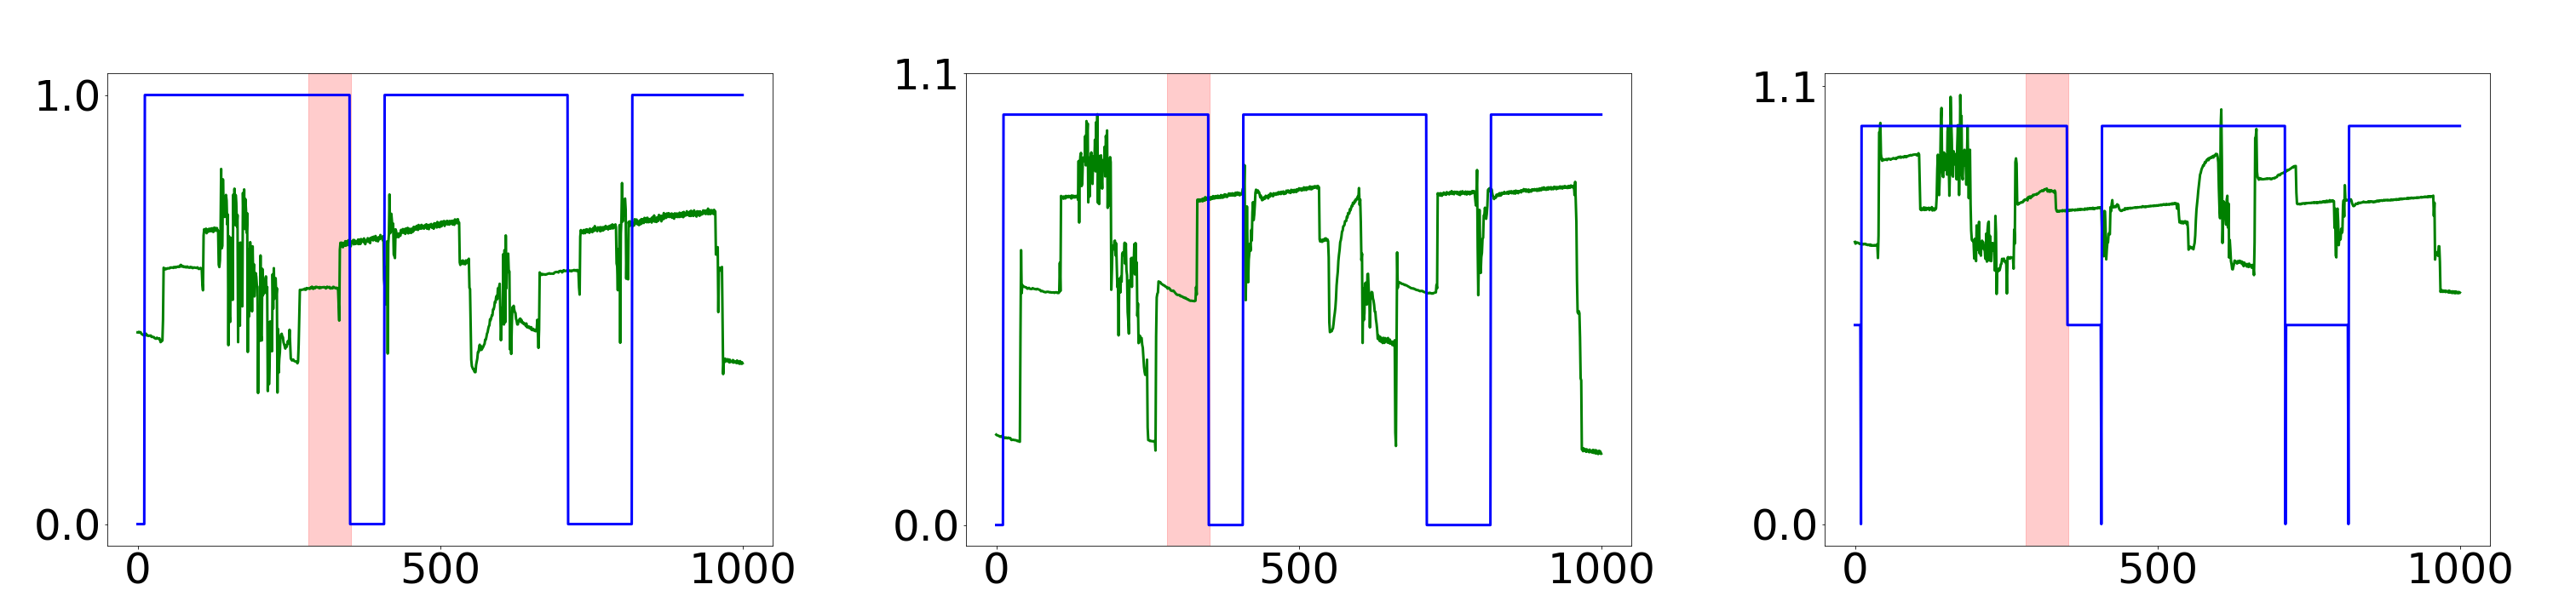

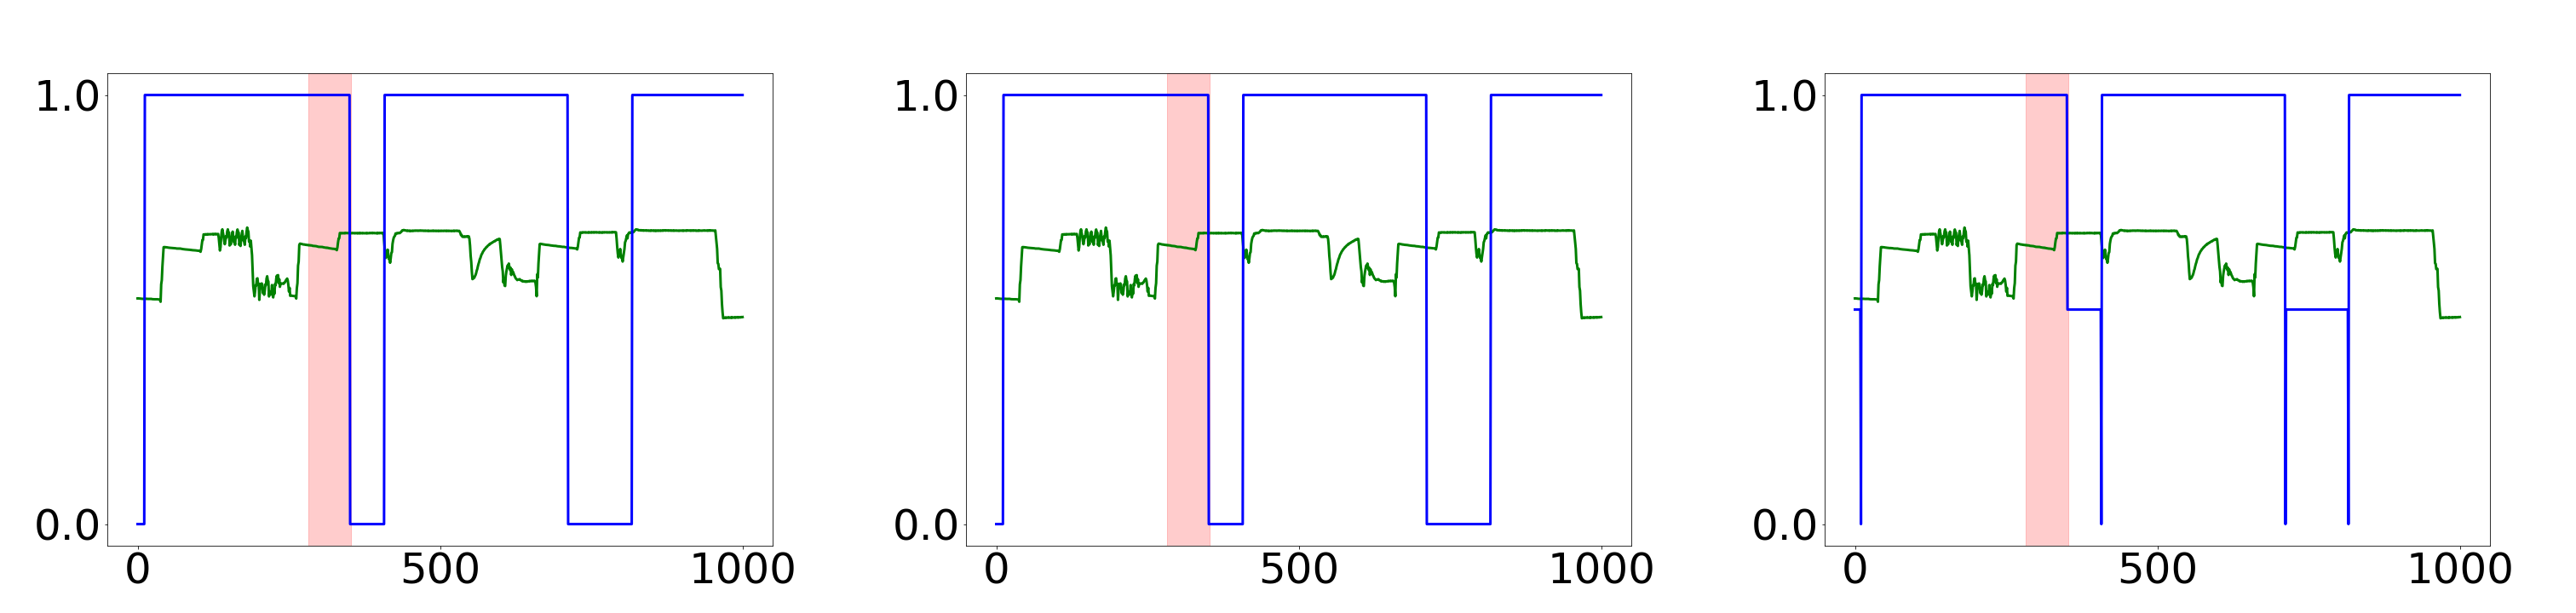

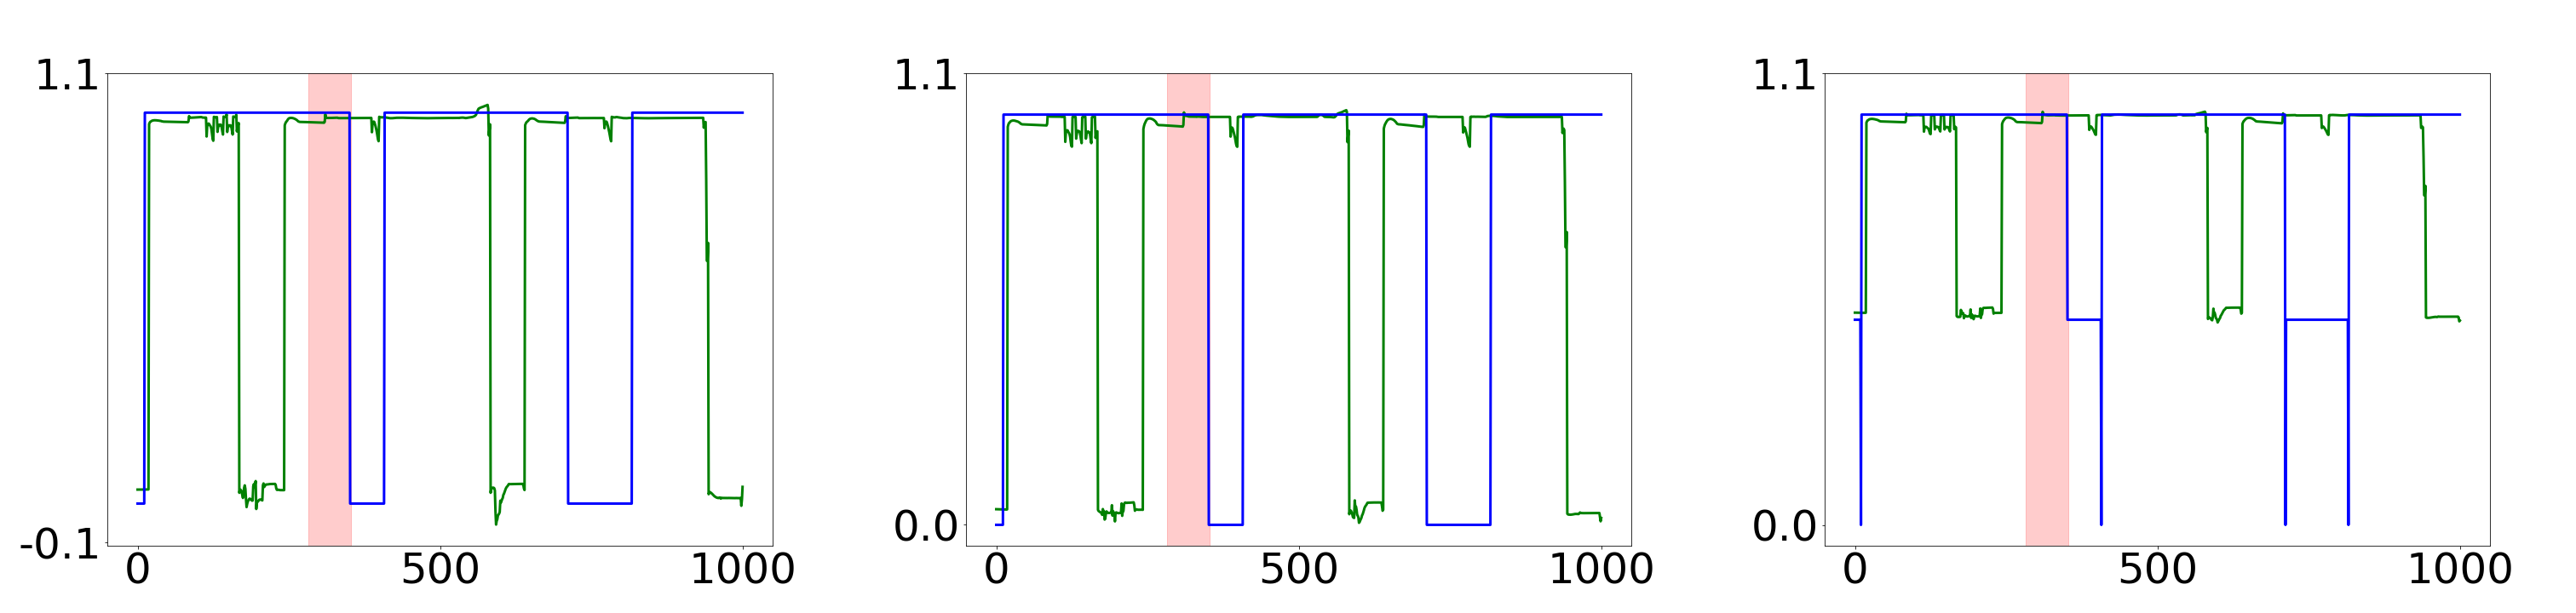

In [7]:
gru_figs = []
for column in non_anomaly_columns:
    
    generate_forecast_and_series_fig(
        output_gru_val[custom_start_index:custom_end_index, column],
        data_gru_val[custom_start_index:custom_end_index, column],
        labels_gru_single_val[custom_start_index:custom_end_index],
        "GRU",
        "SWAT",
        f"gru_non_anomaly_{column}.png",
        title=cols[column]
    )
    gru_figs.append(
        f"gru_non_anomaly_{column}.png"
    )
    
 
display(generate_grid(gru_figs, cols=3, file_name="gru_non_anomaly_grid.png"))


# Generate grid for GDN figures
gdn_figs = []
for column in non_anomaly_columns:
    
    generate_forecast_and_series_fig(
        output_gdn_val[custom_start_index:custom_end_index, column],
        data_gdn_val[custom_start_index:custom_end_index, column],
        labels_gdn_single_val[custom_start_index:custom_end_index],
        "GDN",
        "SWAT",
        f"gdn_non_anomaly_{column}.png"
    )
    gdn_figs.append(
        f"gdn_non_anomaly_{column}.png"
    )

display(generate_grid(gdn_figs, cols=3, file_name="gdn_non_anomaly_grid.png"))

# Generate grid for GCN figures
gcn_figs = []
for column in non_anomaly_columns:
   
    generate_forecast_and_series_fig(
        output_gcn_val[custom_start_index:custom_end_index, column],
        data_gcn_val[custom_start_index:custom_end_index, column],
        labels_gcn_single_val[custom_start_index:custom_end_index],
        "GCN",
        "SWAT",
        f"gcn_non_anomaly_{column}.png" 
    )
    gcn_figs.append(
        f"gcn_non_anomaly_{column}.png"
    )

display(generate_grid(gcn_figs, cols=3, file_name="gcn_non_anomaly_grid.png"))

mtad_gat_figs = []
mtad_gat_forecasts, mtad_gat_reconstruction = output_mtad_gat_val
for column in non_anomaly_columns:
    generate_forecast_and_series_fig(
        mtad_gat_forecasts[custom_start_index:custom_end_index, column],
        data_mtad_gat_val[custom_start_index:custom_end_index, column],
        labels_mtad_gat_single_val[custom_start_index:custom_end_index],
        "MTAD-GAT",
        "SWAT",
        f"mtad_gat_non_anomaly_{column}.png"
    )
    mtad_gat_figs.append(
        f"mtad_gat_non_anomaly_{column}.png"
    )

display(generate_grid(mtad_gat_figs, cols=3, file_name="mtad_gat_non_anomaly_grid.png"))

In [223]:
import os
import shutil

source_folder = "figures"
destination_folder = "gru_predictions"

if os.path.exists(destination_folder):
    shutil.rmtree(destination_folder)
os.makedirs(destination_folder)


for filename in os.listdir(source_folder):
    if filename.startswith("gru"):
        shutil.copy(os.path.join(source_folder, filename), destination_folder)


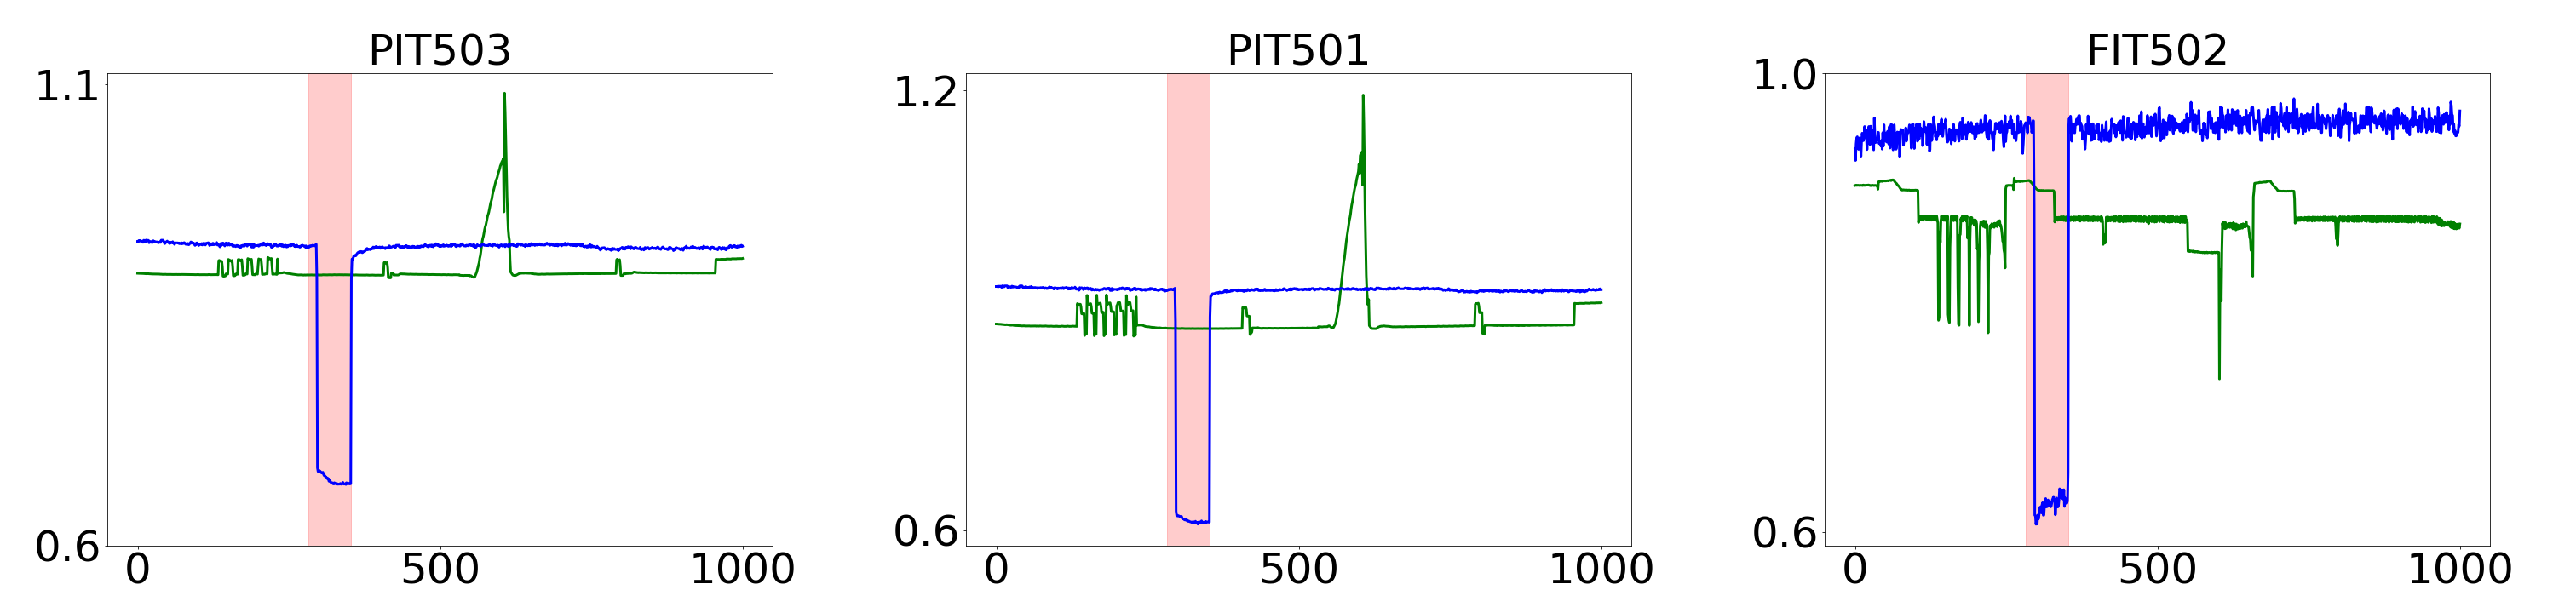

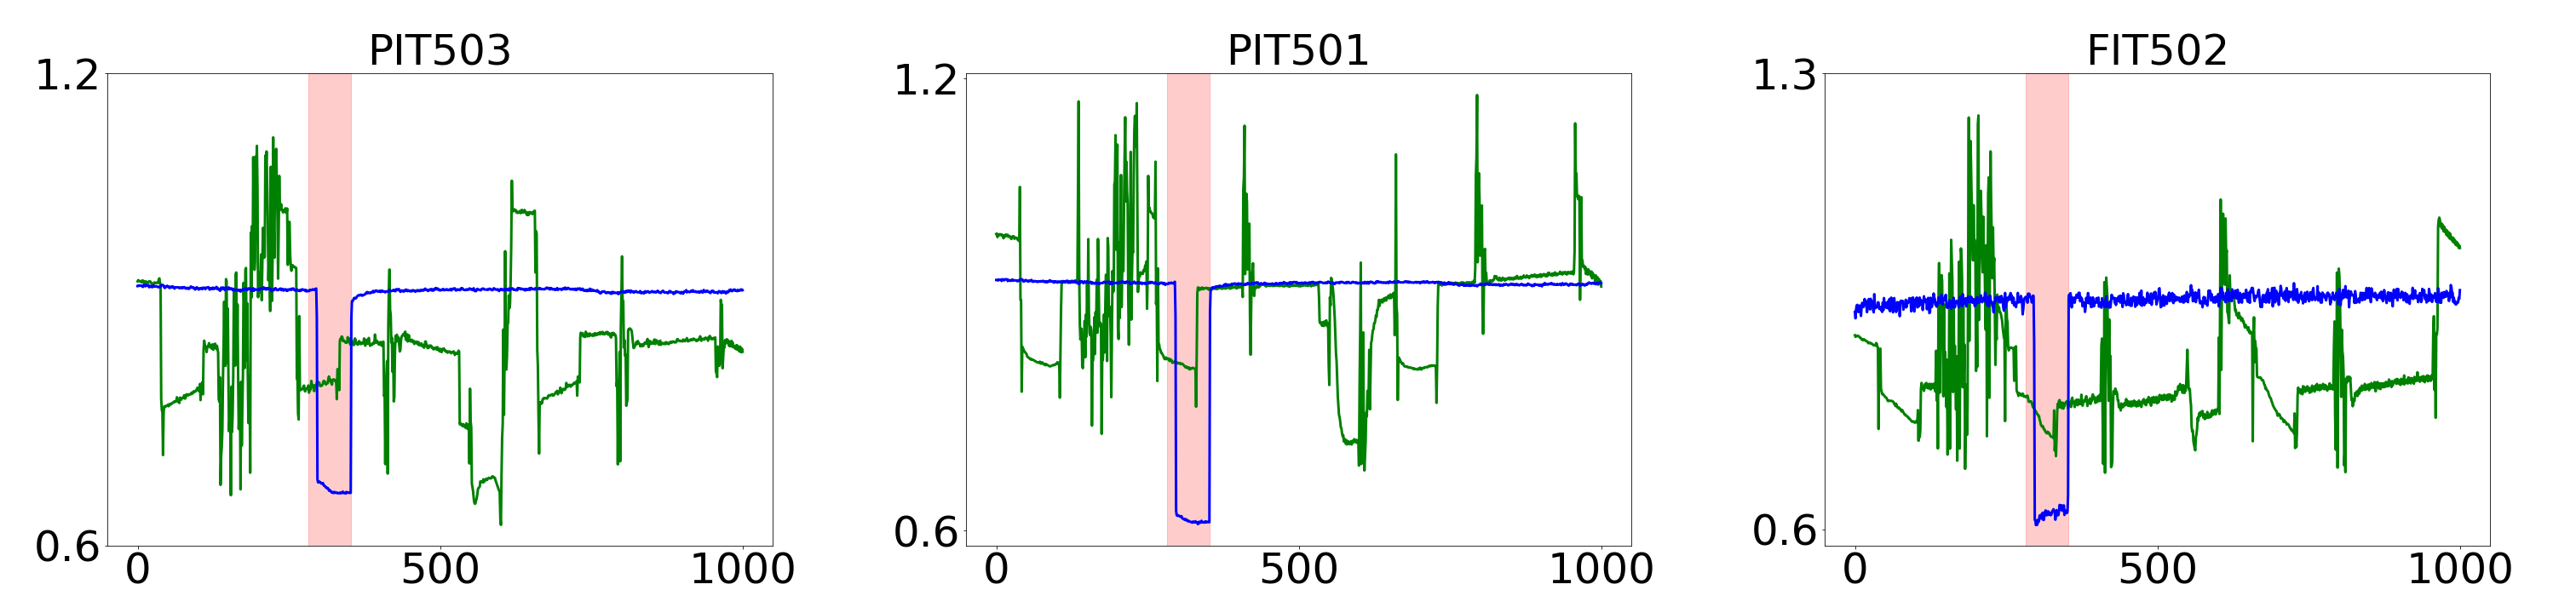

In [229]:
custom_start_index = 1000
custom_end_index = 2000
gdn_graph_figs = []


for column in anomaly_columns:
    
    generate_forecast_and_series_fig(
        output_gdn_graph_val[custom_start_index:custom_end_index, column],
        data_gdn_graph_val[custom_start_index:custom_end_index, column],
        labels_gdn_graph_single_val[custom_start_index:custom_end_index],
        "GDN",
        "SWAT",
        f"gdn_graph_anomaly_{column}.png",
        title=cols[column]
    )
    gdn_graph_figs.append(
        f"gdn_graph_anomaly_{column}.png"
    )
    
 
display(generate_grid(gdn_graph_figs, cols=3, file_name="gdn_graph_anomaly_grid.png"))

gdn_figs = []
for column in anomaly_columns:
    
    generate_forecast_and_series_fig(
        output_gdn_val[custom_start_index:custom_end_index, column],
        data_gdn_val[custom_start_index:custom_end_index, column],
        labels_gdn_single_val[custom_start_index:custom_end_index],
        "GDN",
        "SWAT",
        f"gdn_anomaly_{column}.png",
        title=cols[column]
    )
    gdn_figs.append(
        f"gdn_anomaly_{column}.png"
    )
    
 
display(generate_grid(gdn_figs, cols=3, file_name="gdn_anomaly_grid.png"))

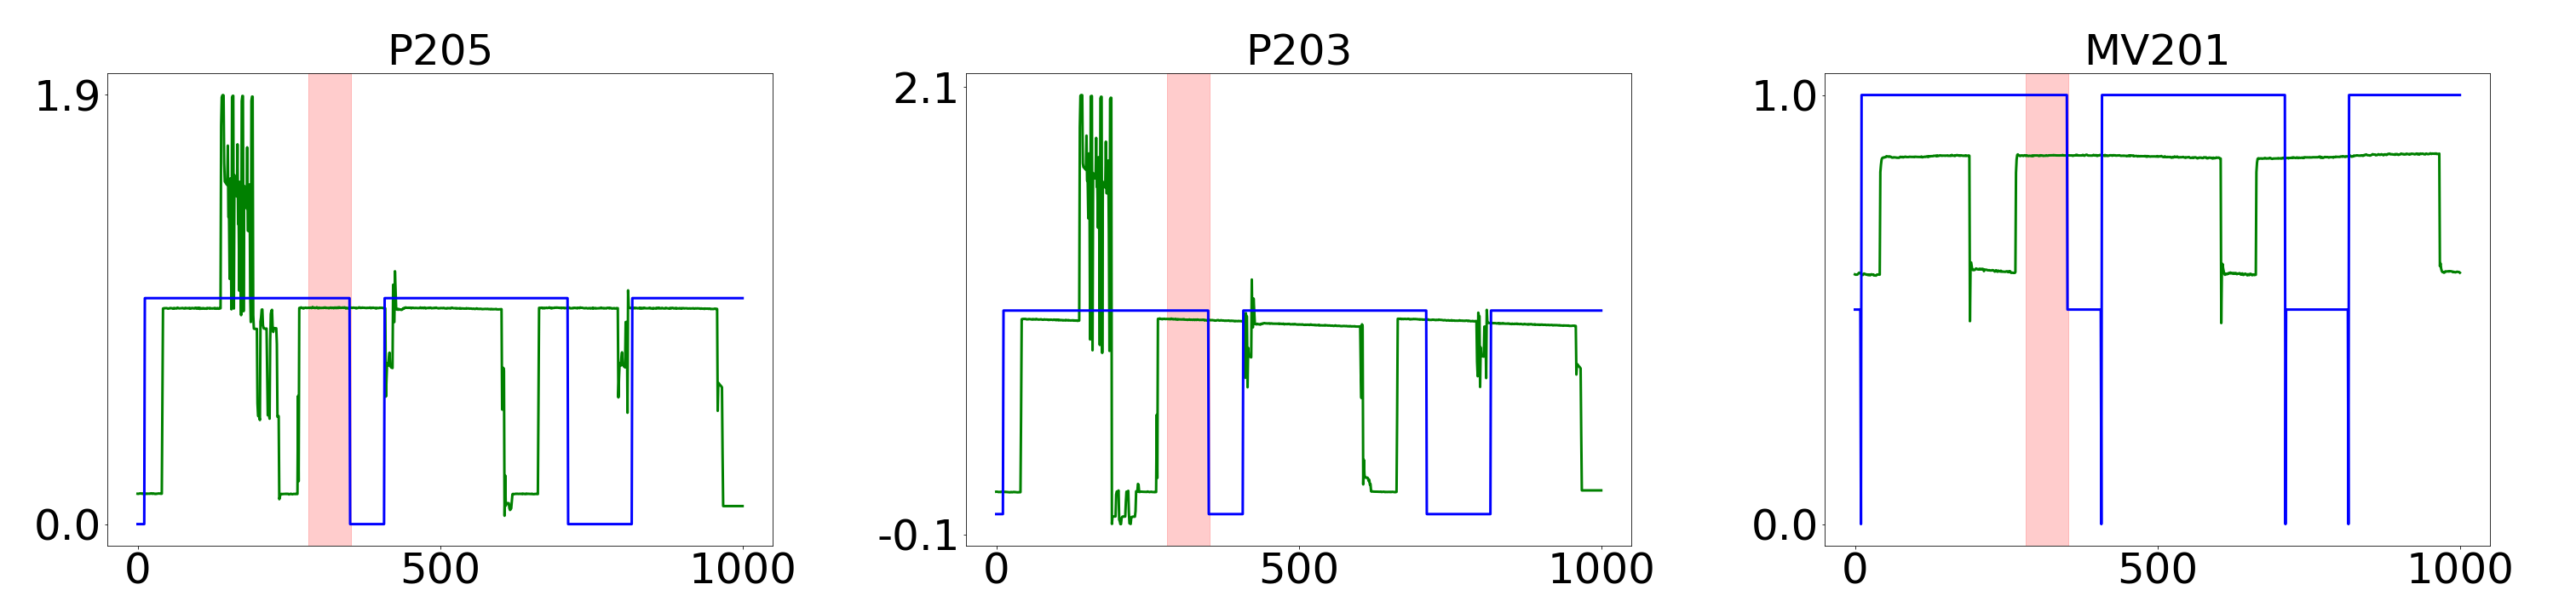

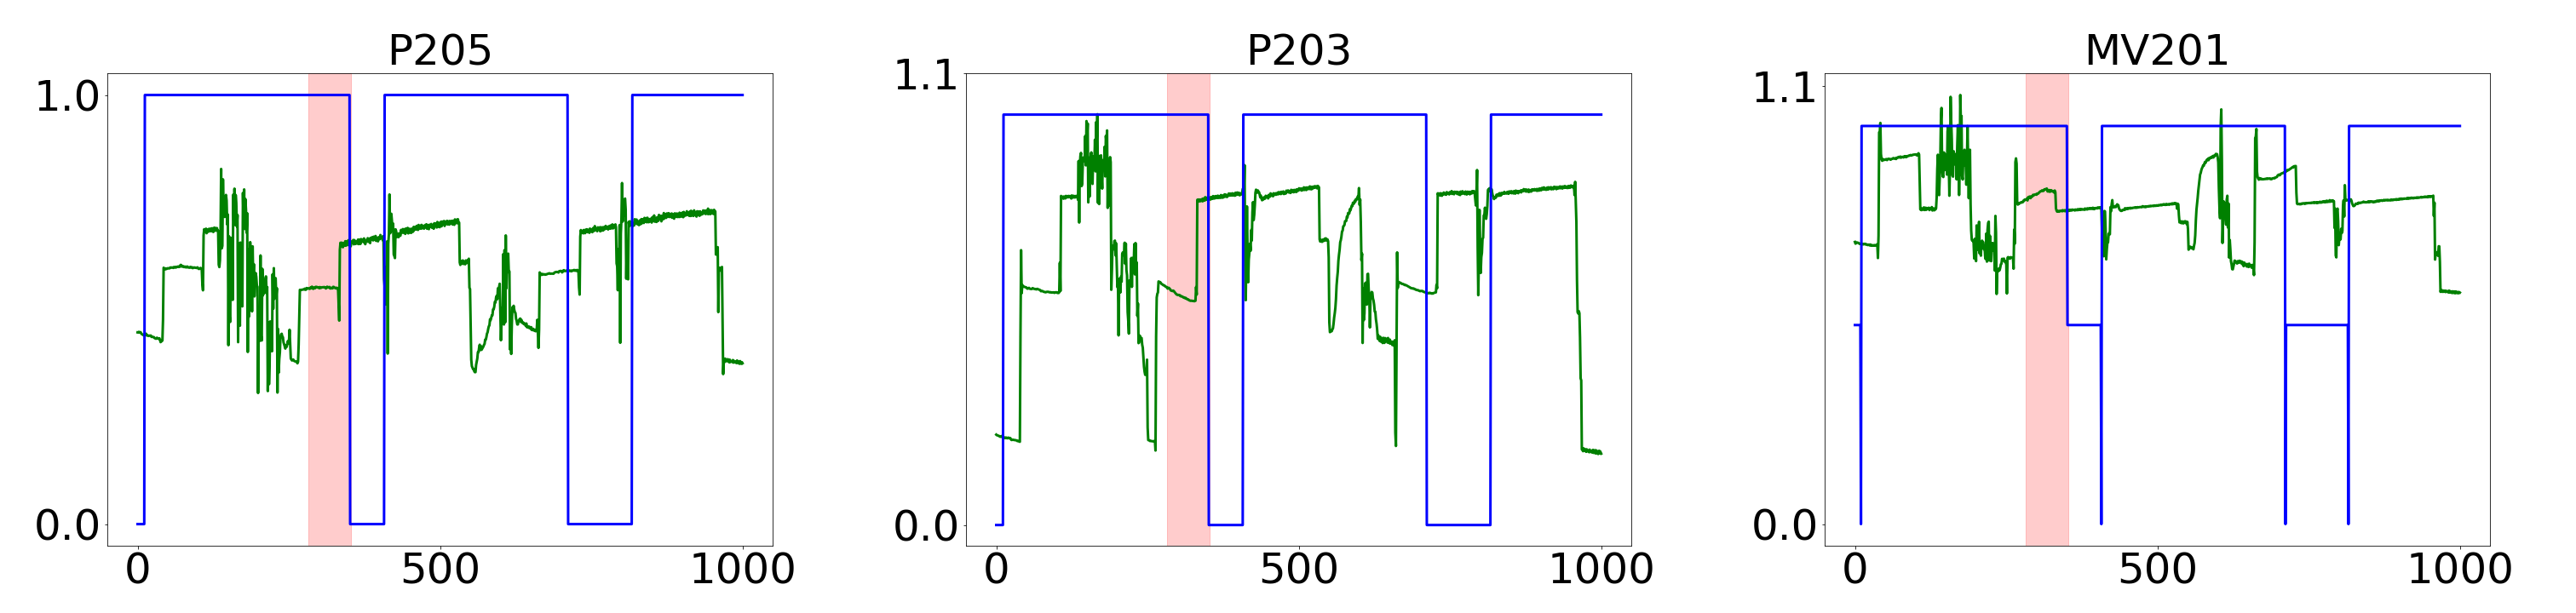

In [227]:
custom_start_index = 1000
custom_end_index = 2000
gdn_graph_figs = []


for column in non_anomaly_columns:
    
    generate_forecast_and_series_fig(
        output_gdn_graph_val[custom_start_index:custom_end_index, column],
        data_gdn_graph_val[custom_start_index:custom_end_index, column],
        labels_gdn_graph_single_val[custom_start_index:custom_end_index],
        "GDN",
        "SWAT",
        f"gdn_graph_non_anomaly_{column}.png",
        title=cols[column]
    )
    gdn_graph_figs.append(
        f"gdn_graph_non_anomaly_{column}.png"
    )
    
 
display(generate_grid(gdn_graph_figs, cols=3, file_name="gdn_graph_non_anomaly_grid.png"))

gdn_figs = []
for column in non_anomaly_columns:
    
    generate_forecast_and_series_fig(
        output_gdn_val[custom_start_index:custom_end_index, column],
        data_gdn_val[custom_start_index:custom_end_index, column],
        labels_gdn_single_val[custom_start_index:custom_end_index],
        "GDN",
        "SWAT",
        f"gdn_non_anomaly_{column}.png",
        title=cols[column]
    )
    gdn_figs.append(
        f"gdn_non_anomaly_{column}.png"
    )
    
 
display(generate_grid(gdn_figs, cols=3, file_name="gdn_non_anomaly_grid.png"))

In [230]:
import os
import shutil

source_folder = "figures"
destination_folder = "gdn_graph_predictions"

if os.path.exists(destination_folder):
    shutil.rmtree(destination_folder)
os.makedirs(destination_folder)


for filename in os.listdir(source_folder):
    if filename.startswith("gdn_graph"):
        shutil.copy(os.path.join(source_folder, filename), destination_folder)

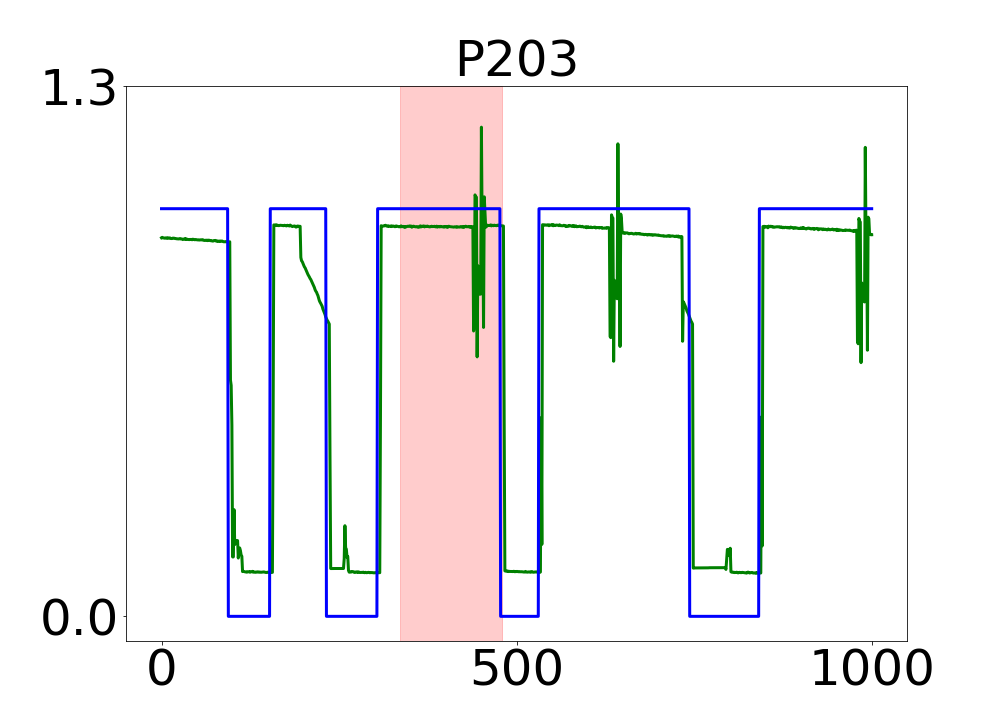

In [240]:
custom_start_index = -3000
custom_end_index = -2000
column = 9
generate_forecast_and_series_fig(
    output_gdn_graph_val[custom_start_index:custom_end_index, column],
    data_gdn_graph_val[custom_start_index:custom_end_index, column],
    labels_gdn_graph_single_val[custom_start_index:custom_end_index],
    "GDN",
    "SWAT",
    f"deleteme_{column}.png",
    title=cols[column]
)
Image.open("buffer/deleteme_9.png")

In [249]:
models = ["gru", "gcn", "gdn", "mtad_gat"]
datasets = ["swat", "telco"]

for model in models:
    for dataset in datasets:
        base_path = f"../results/test_{dataset}/{model}/version_0/plots"
        end_path = f"../results/score_histograms/{model}_{dataset}"

        if os.path.exists(end_path):
            shutil.rmtree(end_path)
        shutil.copytree(base_path, end_path)

## General prediction

In [5]:
def generate_timeline_plots(predictions_list: list[np.ndarray], names: list[str]):
    """
    Plot horizontal timeline bars showing normal/anomaly regions for multiple prediction sets.
    
    Args:
        predictions_list: List of 1D numpy arrays containing predictions (0=normal, 1=anomaly)
        names: List of names/labels for each prediction set
    """
    font_size = 20
    plt.style.use("ggplot")
    
    # Create figure with appropriate height
    fig, ax = plt.subplots(figsize=(20, max(8, len(predictions_list) * 0.8)))
    
    ax.set_facecolor("white")
    fig.set_facecolor("white")
    
    bar_height = 0.6  # Height of each bar
    
    for idx, (predictions, name) in enumerate(zip(predictions_list, names)):
        time_indices = np.arange(len(predictions))
        
        # Plot normal regions (green)
        normal_mask = predictions < 0.5
        ax.fill_between(time_indices, 
                       idx - bar_height/2, 
                       idx + bar_height/2, 
                       where=normal_mask,
                       color="#2ecc71",
                       alpha=0.6)
        
        # Plot anomaly regions (red)
        anomaly_mask = predictions >= 0.5
        ax.fill_between(time_indices, 
                       idx - bar_height/2, 
                       idx + bar_height/2, 
                       where=anomaly_mask,
                       color="#ff0000",
                       alpha=1.0)
    
    # Configure axis and labels
    ax.set_yticks(range(len(predictions_list)))
    ax.set_yticklabels(names, fontsize=font_size)
    
    # Remove top and right spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)
    
    ax.set_xlabel("Time Index", fontsize=font_size, fontweight="bold")
    
    # Customize grid
    ax.grid(True, axis="x", alpha=0.2, linestyle="--")
    ax.set_axisbelow(True)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="#2ecc71", alpha=0.6, label="Normal"),
        Patch(facecolor="#ff0000", alpha=1.0, label="Anomaly"),
    ]
    ax.legend(handles=legend_elements, fontsize=font_size)
    
    ax.tick_params(axis="x", labelsize=font_size)
    plt.subplots_adjust(bottom=0.2)
    
    return fig

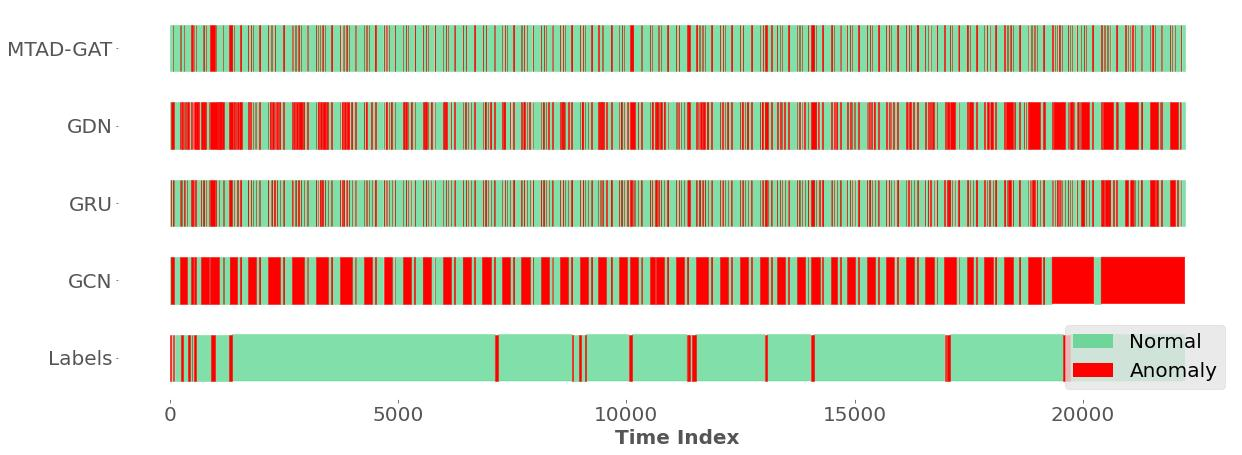

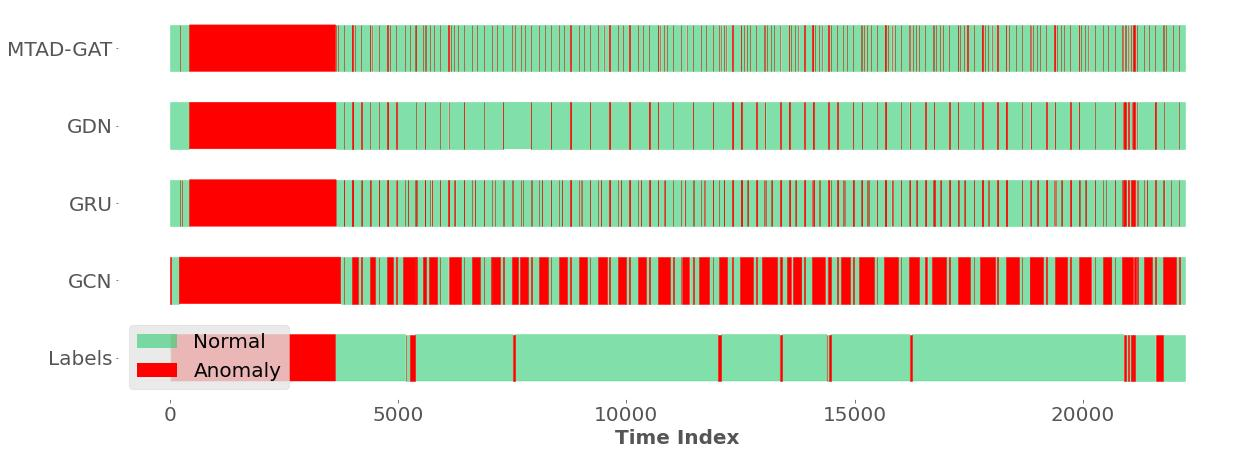

In [25]:
fig = generate_timeline_plots(
        predictions_list=[labels_gcn_single_val.numpy(), predictions_gcn_single_val.numpy(), predictions_gru_single_val.numpy(), predictions_gdn_single_val.numpy(), predictions_mtad_gat_single_val.numpy()],
        names=["Labels", "GCN", "GRU", "GDN", "MTAD-GAT"]
)
fig = generate_timeline_plots(
        predictions_list=[labels_gcn_single_test.numpy(), predictions_gcn_single_test.numpy(), predictions_gru_single_test.numpy(), predictions_gdn_single_test.numpy(), predictions_mtad_gat_single_test.numpy()],
        names=["Labels", "GCN", "GRU", "GDN", "MTAD-GAT"]
)

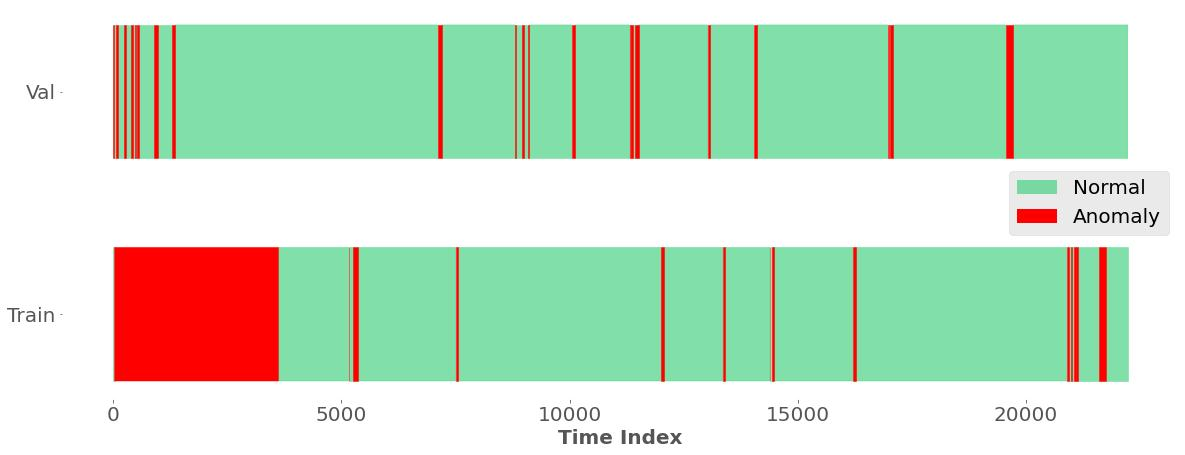

In [6]:
fig = generate_timeline_plots(
        predictions_list=[labels_gcn_single_test.numpy(), labels_gcn_single_val.numpy()],
        names=["Train", "Val"]
)
fig.savefig("anomalies_distribution/swat_labels_temporal_distribution_combined.pdf", bbox_inches="tight", dpi=1000)